[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_6476/906604505.py:17: DtypeWarning: Columns (0: DefTwoPoint) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("NFLPlaybyPlay.csv")


(46129, 66)
Index(['Unnamed: 0', 'Date', 'GameID', 'Drive', 'qtr', 'down', 'time',
       'TimeUnder', 'TimeSecs', 'PlayTimeDiff', 'SideofField', 'yrdln',
       'yrdline100', 'ydstogo', 'ydsnet', 'GoalToGo', 'FirstDown', 'posteam',
       'DefensiveTeam', 'desc', 'PlayAttempted', 'Yards.Gained', 'sp',
       'Touchdown', 'ExPointResult', 'TwoPointConv', 'DefTwoPoint', 'Safety',
       'PuntResult', 'PlayType', 'Passer', 'PassAttempt', 'PassOutcome',
       'PassLength', 'PassLocation', 'InterceptionThrown', 'Interceptor',
       'Rusher', 'RushAttempt', 'RunLocation', 'RunGap', 'Receiver',
       'Reception', 'ReturnResult', 'Returner', 'BlockingPlayer', 'Tackler1',
       'Tackler2', 'FieldGoalResult', 'FieldGoalDistance', 'Fumble',
       'RecFumbTeam', 'RecFumbPlayer', 'Sack', 'Challenge.Replay',
       'ChalReplayResult', 'Accepted.Penalty', 'PenalizedTeam', 'PenaltyType',
       'PenalizedPlayer', 'Penalty.Yards', 'PosTeamScore', 'DefTeamScore',
       'ScoreDiff', 'AbsScoreDiff'

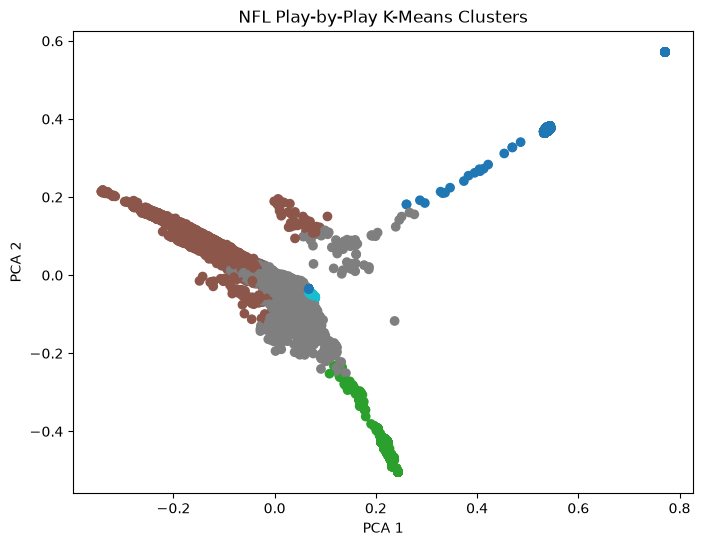

In [ ]:
# Install if needed:
# !pip install pandas scikit-learn nltk matplotlib

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

nltk.download('stopwords')

# 1. Load dataset
df = pd.read_csv("NFLPlaybyPlay.csv")

print(df.shape)
print(df.columns)

# 2. Select text column
# Change 'desc' if your dataset uses another column name
text_col = 'desc'

df = df.dropna(subset=[text_col]).copy()

# 3. NLP text cleaning
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    return ' '.join(
        word for word in text.split()
        if word not in stop_words and len(word) > 2
    )

df['clean_text'] = df[text_col].apply(clean_text)

# 4. TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_text'])

# 5. K-Means
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# 6. Show important words in each cluster
terms = tfidf.get_feature_names_out()

for i in range(k):
    words = kmeans.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"\nCluster {i}:")
    print(', '.join(terms[w] for w in words))

# 7. Show sample plays
print("\nSample clustered plays:")
print(df[[text_col, 'cluster']].head(20))

# 8. Visualise clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='tab10')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("NFL Play-by-Play K-Means Clusters")
plt.show()

# 9. Save results
df.to_csv("NFLPlaybyPlay_KMeans_Results.csv", index=False)